# Classificador Inteligente de Sentimentos em Comentários de Clientes

Este projeto tem como objetivo desenvolver um modelo de Inteligência Artificial capaz de classificar comentários de clientes em três categorias: positivo, negativo ou neutro.

A solução utiliza aprendizado de máquina supervisionado, pré-processamento textual, vetorização TF-IDF e um modelo de classificação.

Base de dados para teste

In [1]:
import pandas as pd

dados = {
    "comentario": [
        "O atendimento foi excelente e resolveram meu problema rapidamente",
        "Gostei muito do serviço, foi uma ótima experiência",
        "A equipe foi muito atenciosa e prestativa",
        "O sistema é fácil de usar e funciona muito bem",
        "Fiquei muito satisfeito com o suporte recebido",
        "O produto atendeu minhas expectativas",
        "A solução ajudou bastante no meu trabalho",
        "O atendimento foi rápido e eficiente",
        "Recomendo o serviço, gostei bastante",
        "A experiência foi positiva e tranquila",

        "O atendimento foi ruim e demorado",
        "Não gostei do serviço prestado",
        "O sistema trava muito e é difícil de usar",
        "Estou insatisfeito com o suporte",
        "Demoraram muito para resolver meu problema",
        "A experiência foi péssima",
        "O produto não funcionou como esperado",
        "Tive muitos problemas com a plataforma",
        "O suporte não respondeu minha solicitação",
        "Não recomendo esse serviço",

        "O atendimento foi normal",
        "O serviço atendeu parcialmente",
        "Não tenho uma opinião formada sobre o produto",
        "A experiência foi regular",
        "O sistema funciona, mas poderia melhorar",
        "O suporte respondeu, mas demorou um pouco",
        "O produto é razoável",
        "Achei o serviço mediano",
        "Foi uma experiência comum",
        "Não foi ruim, mas também não foi excelente"
    ],
    "sentimento": [
        "positivo", "positivo", "positivo", "positivo", "positivo",
        "positivo", "positivo", "positivo", "positivo", "positivo",

        "negativo", "negativo", "negativo", "negativo", "negativo",
        "negativo", "negativo", "negativo", "negativo", "negativo",

        "neutro", "neutro", "neutro", "neutro", "neutro",
        "neutro", "neutro", "neutro", "neutro", "neutro"
    ]
}

df = pd.DataFrame(dados)

df.head()

,comentario,sentimento
0,O atendimento foi excelente e resolveram meu p...,positivo
1,"Gostei muito do serviço, foi uma ótima experiê...",positivo
2,A equipe foi muito atenciosa e prestativa,positivo
3,O sistema é fácil de usar e funciona muito bem,positivo
4,Fiquei muito satisfeito com o suporte recebido,positivo


Mostra quantos comentários existem em cada classe.

In [2]:
df["sentimento"].value_counts()

,count
sentimento,
positivo,10
negativo,10
neutro,10


Limpeza dos textos, onde é removido os caracteres especiais e pontuação.

In [3]:
import re
import string

def limpar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'\d+', '', texto)
    texto = texto.translate(str.maketrans('', '', string.punctuation))
    texto = texto.strip()
    return texto

df["comentario_limpo"] = df["comentario"].apply(limpar_texto)

df[["comentario", "comentario_limpo", "sentimento"]].head()

,comentario,comentario_limpo,sentimento
0,O atendimento foi excelente e resolveram meu p...,o atendimento foi excelente e resolveram meu p...,positivo
1,"Gostei muito do serviço, foi uma ótima experiê...",gostei muito do serviço foi uma ótima experiência,positivo
2,A equipe foi muito atenciosa e prestativa,a equipe foi muito atenciosa e prestativa,positivo
3,O sistema é fácil de usar e funciona muito bem,o sistema é fácil de usar e funciona muito bem,positivo
4,Fiquei muito satisfeito com o suporte recebido,fiquei muito satisfeito com o suporte recebido,positivo


Separação dos dados de treino e teste

In [4]:
from sklearn.model_selection import train_test_split

X = df["comentario_limpo"]
y = df["sentimento"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Quantidade de dados de treino:", len(X_train))
print("Quantidade de dados de teste:", len(X_test))

Quantidade de dados de treino: 21
Quantidade de dados de teste: 9


Transformação de texto em numeros com TF-IDF. Isso dá peso para as palavras importantes de cada comentário.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

vetorizador = TfidfVectorizer()

X_train_tfidf = vetorizador.fit_transform(X_train)
X_test_tfidf = vetorizador.transform(X_test)

print("Formato da matriz de treino:", X_train_tfidf.shape)
print("Formato da matriz de teste:", X_test_tfidf.shape)

Formato da matriz de treino: (21, 63)
Formato da matriz de teste: (9, 63)


Treino do modelo de IA, é usado Regressão Logística, que é um modelo simples para classificação de texto.

In [6]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(max_iter=1000)

modelo.fit(X_train_tfidf, y_train)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


Teste do Modelo

In [7]:
y_pred = modelo.predict(X_test_tfidf)

resultado = pd.DataFrame({
    "Comentário": X_test,
    "Sentimento real": y_test,
    "Sentimento previsto": y_pred
})

resultado

,Comentário,Sentimento real,Sentimento previsto
16,o produto não funcionou como esperado,negativo,negativo
7,o atendimento foi rápido e eficiente,positivo,neutro
1,gostei muito do serviço foi uma ótima experiência,positivo,neutro
26,o produto é razoável,neutro,positivo
13,estou insatisfeito com o suporte,negativo,negativo
22,não tenho uma opinião formada sobre o produto,neutro,negativo
4,fiquei muito satisfeito com o suporte recebido,positivo,negativo
14,demoraram muito para resolver meu problema,negativo,positivo
29,não foi ruim mas também não foi excelente,neutro,negativo


Avaliação do modelo, onde aparece as métricas de acuracia, precisão, recall, F1-score e matriz de confusão

In [8]:
from sklearn.metrics import accuracy_score, classification_report

acuracia = accuracy_score(y_test, y_pred)

print("Acurácia do modelo:", acuracia)

print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred))

Acurácia do modelo: 0.2222222222222222

Relatório de classificação:
              precision    recall  f1-score   support

    negativo       0.40      0.67      0.50         3
      neutro       0.00      0.00      0.00         3
    positivo       0.00      0.00      0.00         3

    accuracy                           0.22         9
   macro avg       0.13      0.22      0.17         9
weighted avg       0.13      0.22      0.17         9



Matriz de confusão

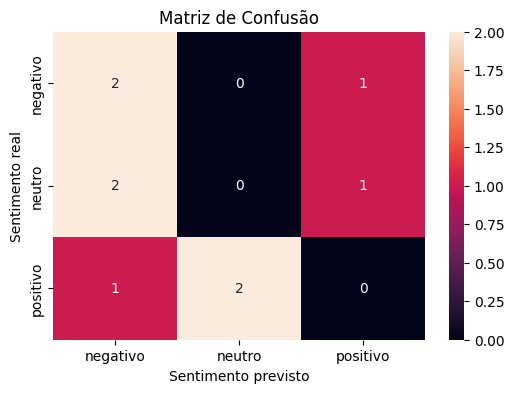

In [9]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

matriz = confusion_matrix(y_test, y_pred, labels=modelo.classes_)

plt.figure(figsize=(6, 4))
sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    xticklabels=modelo.classes_,
    yticklabels=modelo.classes_
)

plt.xlabel("Sentimento previsto")
plt.ylabel("Sentimento real")
plt.title("Matriz de Confusão")
plt.show()

Função para classificar novos comentários

In [10]:
def classificar_comentario(comentario):
    comentario_limpo = limpar_texto(comentario)
    comentario_vetorizado = vetorizador.transform([comentario_limpo])
    sentimento = modelo.predict(comentario_vetorizado)[0]
    probabilidades = modelo.predict_proba(comentario_vetorizado)[0]

    return sentimento, probabilidades

comentario_teste = "O atendimento foi ótimo e resolveram tudo rápido"

sentimento, probabilidades = classificar_comentario(comentario_teste)

print("Comentário:", comentario_teste)
print("Sentimento identificado:", sentimento)
print("Probabilidades:", probabilidades)
print("Classes:", modelo.classes_)

Comentário: O atendimento foi ótimo e resolveram tudo rápido
Sentimento identificado: positivo
Probabilidades: [0.30001401 0.33693285 0.36305315]
Classes: ['negativo' 'neutro' 'positivo']


Teste com comentários diferentes

In [11]:
comentarios_para_testar = [
    "O atendimento foi maravilhoso",
    "O sistema é muito ruim e vive travando",
    "Achei o serviço normal",
    "Demoraram muito para responder minha solicitação",
    "Gostei bastante da experiência"
]

for comentario in comentarios_para_testar:
    sentimento, probabilidades = classificar_comentario(comentario)
    print("Comentário:", comentario)
    print("Sentimento:", sentimento)
    print("-" * 50)

Comentário: O atendimento foi maravilhoso
Sentimento: neutro
--------------------------------------------------
Comentário: O sistema é muito ruim e vive travando
Sentimento: negativo
--------------------------------------------------
Comentário: Achei o serviço normal
Sentimento: neutro
--------------------------------------------------
Comentário: Demoraram muito para responder minha solicitação
Sentimento: negativo
--------------------------------------------------
Comentário: Gostei bastante da experiência
Sentimento: positivo
--------------------------------------------------


Entrada interativa para testar com outros comentarios

In [19]:
comentario_usuario = input("Digite um comentário de cliente: ")

sentimento, probabilidades = classificar_comentario(comentario_usuario)

print("\nResultado da classificação:")
print("Comentário analisado:", comentario_usuario)
print("Sentimento identificado:", sentimento)

Digite um comentário de cliente: O suporte foi péssimo e demorou muito

Resultado da classificação:
Comentário analisado: O suporte foi péssimo e demorou muito
Sentimento identificado: neutro


Importação para CSV


In [20]:
df.to_csv("comentarios_clientes.csv", index=False)

print("Arquivo comentarios_clientes.csv criado com sucesso!")

Arquivo comentarios_clientes.csv criado com sucesso!


In [21]:
from google.colab import files

files.download("comentarios_clientes.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>